# 03 — QCL: Production, Yield & Area

The heart of GROW. Questions we want to answer:
- Which crops/regions dominate production, and how has that shifted since 1961?
- Is growth driven by **more land** (area) or **better yield**? (This is a great hypothesis seed.)
- Where is production *declining* — candidate "regions at risk" for the forecast project.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.load import load_dataset
from src.clean import (standardize_columns, split_aggregates, resolve_china,
                       annotate_flags, data_quality_report)
from src.viz import trend_over_time, missingness_heatmap, flag_composition, save

## 1. Load QCL (full) and filter to a working slice in pandas
Bulk loading gives the whole dataset; we filter to staples + the three physical
elements. Verify the Item/Element names against notebook 01's inventory.

In [2]:
qcl = standardize_columns(load_dataset("QCL"))

STAPLES = ["Wheat", "Rice", "Maize (corn)"]   # check exact spelling in notebook 01
ELEMENTS = ["Production", "Yield", "Area harvested"]

df = qcl[qcl["item"].isin(STAPLES) & qcl["element"].isin(ELEMENTS)].copy()
print(f"filtered: {df.shape}")
print("items found:", df['item'].unique().tolist())
print("elements found:", df['element'].unique().tolist())
df.head()

[cache] QCL_long.parquet
filtered: (91481, 12)
items found: ['Maize (corn)', 'Rice', 'Wheat']
elements found: ['Area harvested', 'Yield', 'Production']


,area_code,area_code_(m49),area,item_code,item_code_(cpc),item,element_code,element,unit,year,value,flag
56,2,'004,Afghanistan,56,'0112,Maize (corn),5312,Area harvested,ha,1961,500000.0,A
57,2,'004,Afghanistan,56,'0112,Maize (corn),5412,Yield,kg/ha,1961,1400.0,A
58,2,'004,Afghanistan,56,'0112,Maize (corn),5510,Production,t,1961,700000.0,A
147,2,'004,Afghanistan,27,'0113,Rice,5312,Area harvested,ha,1961,210000.0,A
148,2,'004,Afghanistan,27,'0113,Rice,5412,Yield,kg/ha,1961,1519.0,A


## 2. Split aggregates from countries, resolve China

In [3]:
countries, aggregates = split_aggregates(df)
countries = resolve_china(countries)
countries = annotate_flags(countries)
print(f"country rows: {len(countries):,} | aggregate rows: {len(aggregates):,}")

country rows: 72,330 | aggregate rows: 17,897


## 3. Data quality — is this even usable? (feasibility)

In [4]:
report = data_quality_report(countries)
for k, v in report.items():
    print(f"{k}: {v}")

rows: 72330
n_missing_value: 0
pct_missing_value: 0.0
flag_distribution: {'A': 0.807, 'E': 0.132, 'X': 0.031, 'I': 0.03}
year_min: 1961
year_max: 2024


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_flag_composition.png


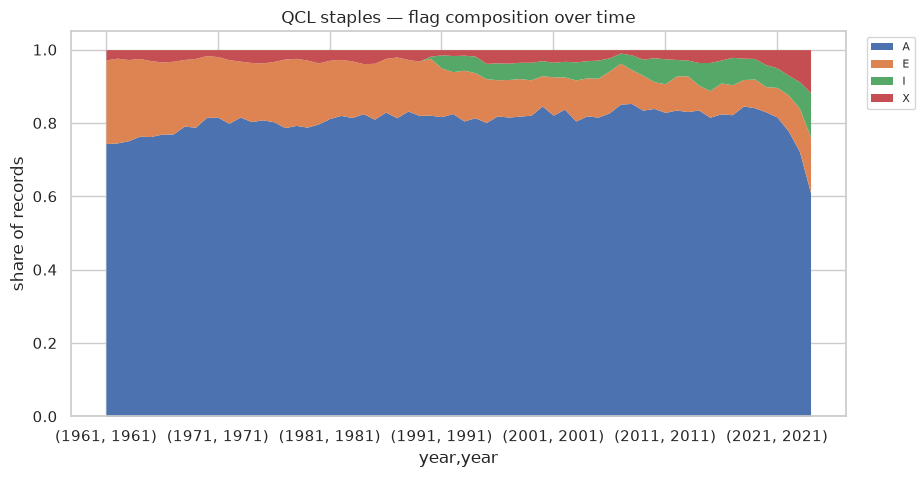

In [5]:
# How much of the data is estimated/imputed vs official, over time?
fig, ax = flag_composition(countries, title="QCL staples — flag composition over time")
save(fig, "qcl_flag_composition")
plt.show()

## 4. Global production trend by crop

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_global_production_by_crop.png


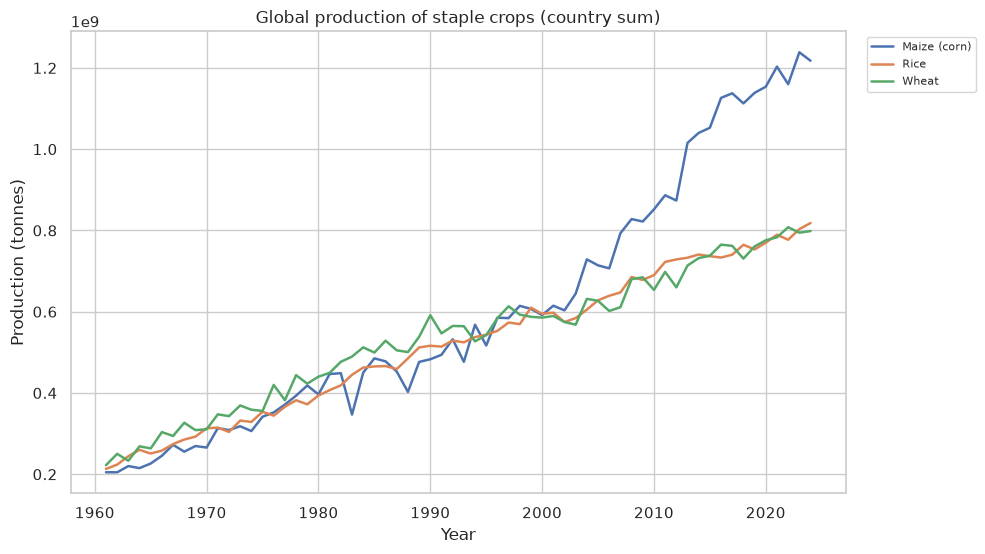

In [6]:
prod = countries[countries["element"].str.contains("Production", case=False, na=False)]
fig, ax = trend_over_time(prod, "year", "value", group_col="item",
                          title="Global production of staple crops (country sum)",
                          ylabel="Production (tonnes)")
save(fig, "qcl_global_production_by_crop")
plt.show()

## 5. Area vs Yield decomposition — WHY is production changing?
Production = Area x Yield. Comparing the two curves tells the story:
intensification (yield) vs expansion (area). Strong hypothesis material.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_decomposition_maize (corn).png


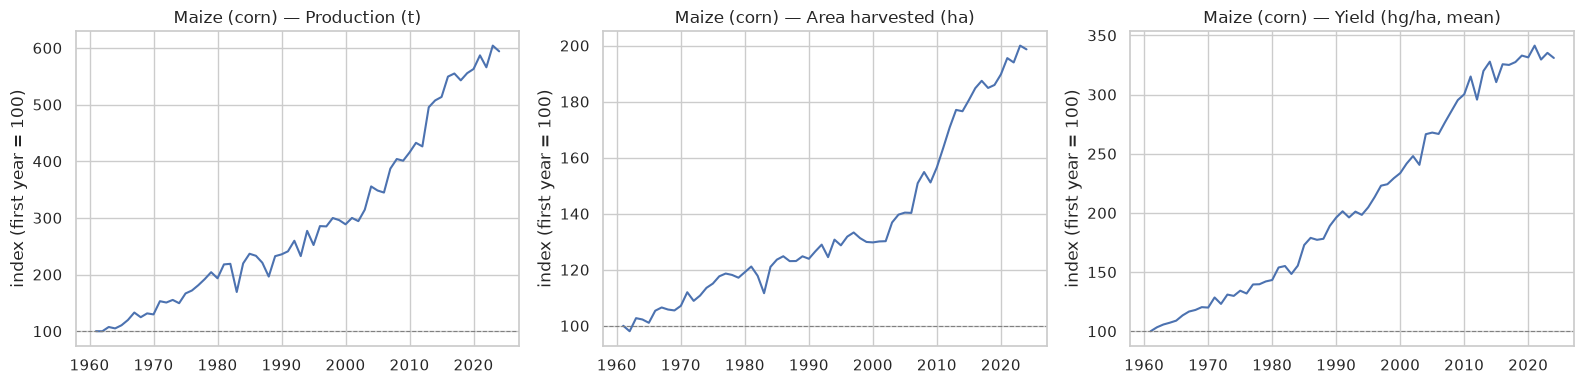

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_decomposition_rice.png


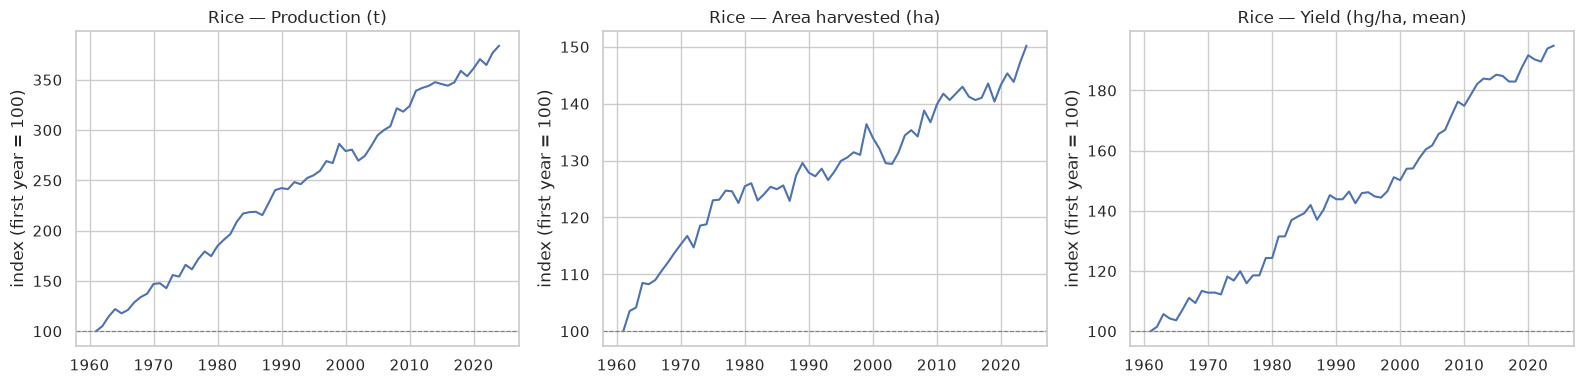

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_decomposition_wheat.png


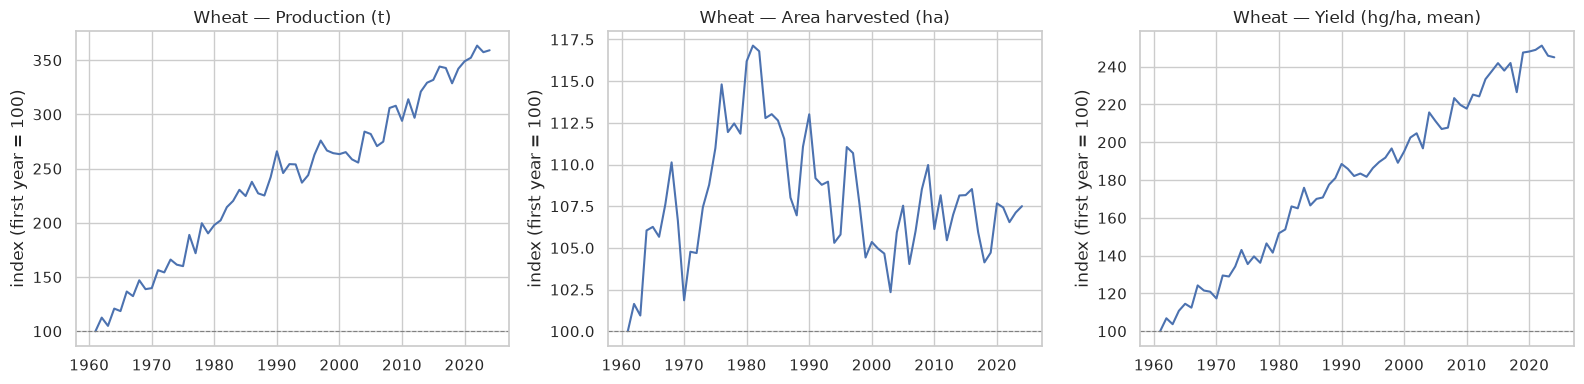

In [7]:
def decomposition(crop_item: str):
    sub = countries[countries["item"] == crop_item]
    area = sub[sub["element"].str.contains("Area", na=False)].groupby("year")["value"].sum()
    yld = sub[sub["element"].str.contains("Yield", na=False)].groupby("year")["value"].mean()
    prod = sub[sub["element"].str.contains("Production", na=False)].groupby("year")["value"].sum()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for a, series, name in zip(axes, [prod, area, yld],
                               ["Production (t)", "Area harvested (ha)", "Yield (hg/ha, mean)"]):
        # index to first year = 100 for comparability
        idx = series / series.iloc[0] * 100
        a.plot(idx.index, idx.values)
        a.set_title(f"{crop_item} — {name}")
        a.set_ylabel("index (first year = 100)")
        a.axhline(100, color="grey", ls="--", lw=0.8)
    fig.tight_layout()
    return fig

for crop in countries["item"].unique():
    fig = decomposition(crop)
    save(fig, f"qcl_decomposition_{crop.lower()}")
    plt.show()

## 6. Where is production DECLINING?
Compute per-country CAGR of production over the last ~20 years. Negative = at risk.
These are exactly the "regions at risk of decline" the GROW project example calls for.

In [8]:
def cagr_by_country(crop_item: str, element_kw: str = "Production", last_n: int = 20):
    sub = countries[(countries["item"] == crop_item) &
                    (countries["element"].str.contains(element_kw, na=False))]
    latest = int(sub["year"].max())
    window = sub[sub["year"] >= latest - last_n]
    out = []
    for area, g in window.groupby("area"):
        g = g.sort_values("year")
        first, last = g["value"].iloc[0], g["value"].iloc[-1]
        yrs = g["year"].iloc[-1] - g["year"].iloc[0]
        if first and first > 0 and yrs > 0:
            cagr = (last / first) ** (1 / yrs) - 1
            out.append({"area": area, "cagr": cagr, "latest_value": last})
    res = pd.DataFrame(out).sort_values("cagr")
    return res

decline = cagr_by_country("Wheat")
print("Fastest-declining wheat producers (by CAGR, last 20y):")
decline.head(15)

Fastest-declining wheat producers (by CAGR, last 20y):


,area,cagr,latest_value
65,Malta,-1.000000,0.00
97,Serbia and Montenegro,-0.272168,2009690.00
54,Kuwait,-0.116986,55.23
23,Colombia,-0.105877,4636.00
62,Madagascar,-0.103202,1000.00
41,Guatemala,-0.082160,761.88
63,Malawi,-0.079140,320.68
12,Bhutan,-0.077311,838.34
58,Lesotho,-0.065505,4183.00
88,Portugal,-0.062040,81350.00


## 7. Yield gap — how much headroom is there?
For a staple, compare the yield of top vs bottom producers in the latest year.
A wide gap between the frontier and the laggards = large potential gains from
closing it, which is a strong, actionable GROW story (and pairs with food security).

In [9]:
def yield_gap(crop_item: str, min_area_ha: float = 10000):
    latest = int(countries["year"].max())
    y = countries[(countries["item"] == crop_item) &
                  (countries["element"].str.contains("Yield", na=False)) &
                  (countries["year"] == latest)]
    a = countries[(countries["item"] == crop_item) &
                  (countries["element"].str.contains("Area", na=False)) &
                  (countries["year"] == latest)][["area", "value"]].rename(columns={"value": "area_ha"})
    m = y.merge(a, on="area", how="left")
    # only meaningful producers (avoid tiny plots with noisy yields)
    m = m[m["area_ha"] >= min_area_ha].copy()
    m = m.sort_values("value", ascending=False)
    return m, latest

gap, yr = yield_gap("Wheat")
print(f"Wheat yield ({yr}) — top 5 vs bottom 5 among meaningful producers (kg/ha):")
print("TOP:\n", gap[["area", "value"]].head(5).to_string(index=False))
print("\nBOTTOM:\n", gap[["area", "value"]].tail(5).to_string(index=False))
if len(gap):
    frontier = gap["value"].quantile(0.9)
    median = gap["value"].median()
    print(f"\n90th-pct frontier yield: {frontier:,.0f} kg/ha | median: {median:,.0f} kg/ha")
    print(f"Gap ratio (frontier/median): {frontier/median:.1f}x")

Wheat yield (2024) — top 5 vs bottom 5 among meaningful producers (kg/ha):
TOP:
                                                 area   value
                                         New Zealand 10014.1
                                             Ireland  8139.7
United Kingdom of Great Britain and Northern Ireland  7281.3
                                              Zambia  7090.0
                                             Germany  7084.2

BOTTOM:
                                  area  value
Democratic People's Republic of Korea 1201.0
                              Eritrea 1000.0
                                Libya  767.7
                              Burundi  730.4
                           Mozambique  312.5

90th-pct frontier yield: 6,260 kg/ha | median: 3,374 kg/ha
Gap ratio (frontier/median): 1.9x


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_wheat_yield_gap.png


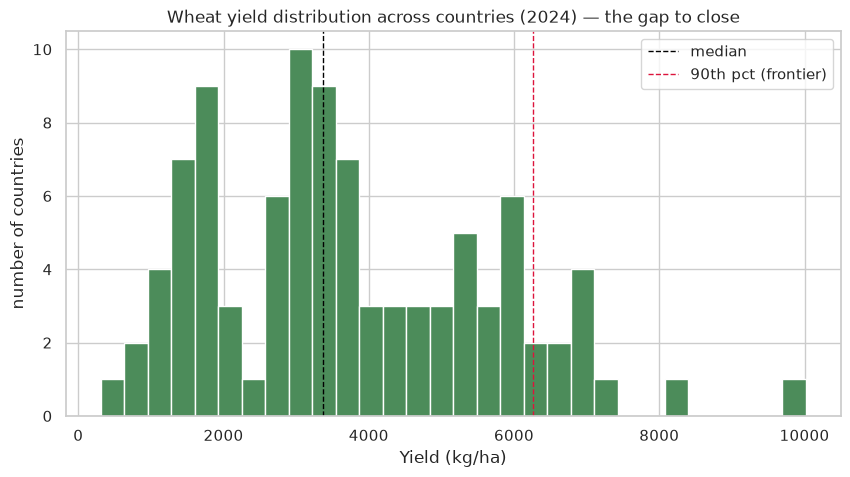

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gap["value"].dropna(), bins=30, color="#4c8c5a", edgecolor="white")
ax.axvline(gap["value"].median(), color="black", ls="--", lw=1, label="median")
ax.axvline(gap["value"].quantile(0.9), color="crimson", ls="--", lw=1, label="90th pct (frontier)")
ax.set_xlabel("Yield (kg/ha)")
ax.set_ylabel("number of countries")
ax.set_title(f"Wheat yield distribution across countries ({yr}) — the gap to close")
ax.legend()
save(fig, "qcl_wheat_yield_gap")
plt.show()

## 8. Regional shift — is production moving between continents?
Uses the aggregates frame (continents are pre-computed by FAOSTAT, no summing
countries). Share of world staple production by region over time answers the
brief's core question directly: "how is production shifting across regions?"

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_regional_share_maize_corn.png


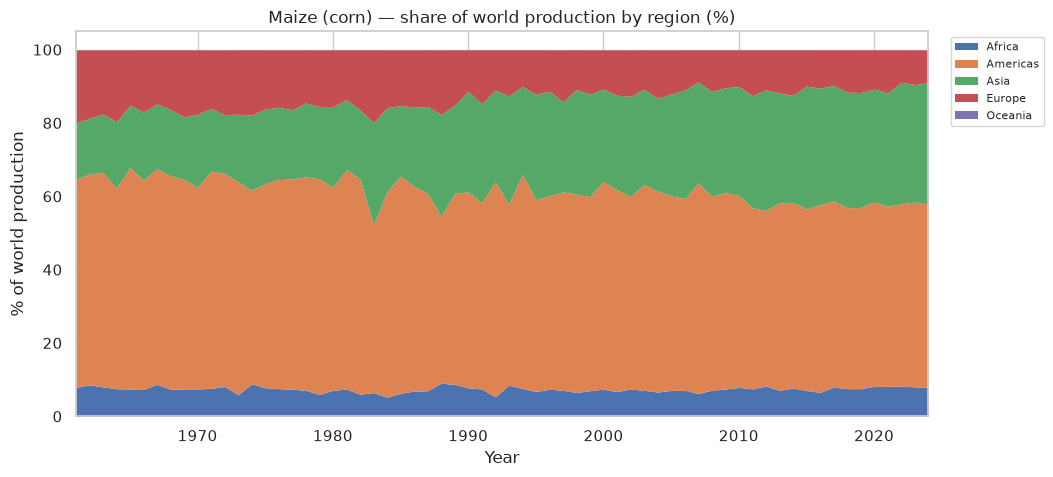

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_regional_share_rice.png


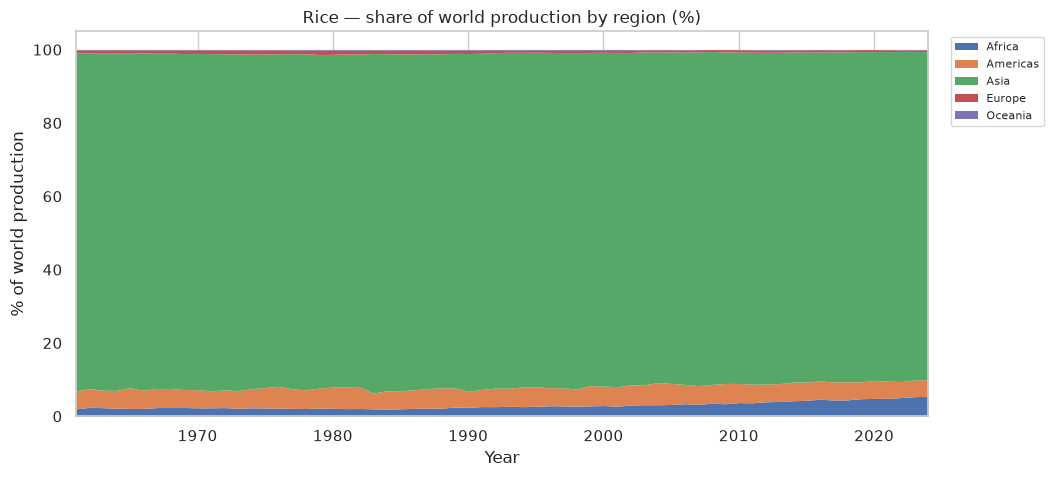

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qcl_regional_share_wheat.png


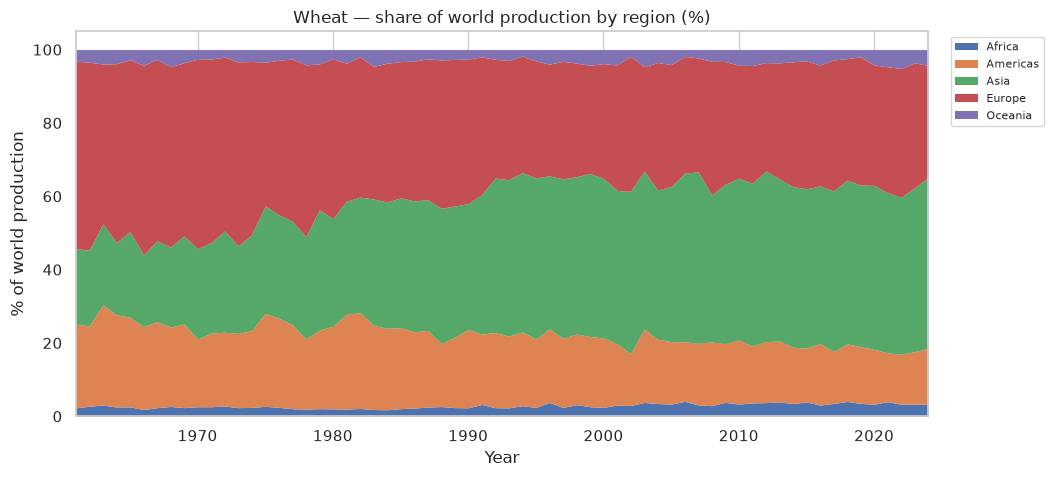

In [11]:
CONTINENTS = ["Africa", "Americas", "Asia", "Europe", "Oceania"]
reg = aggregates[(aggregates["area"].isin(CONTINENTS)) &
                 (aggregates["element"].str.contains("Production", na=False))]

for crop in reg["item"].unique():
    sub = reg[reg["item"] == crop]
    pivot = sub.pivot_table(index="year", columns="area", values="value", aggfunc="sum")
    share = pivot.div(pivot.sum(axis=1), axis=0) * 100
    fig, ax = plt.subplots(figsize=(11, 5))
    share.plot.area(ax=ax, linewidth=0)
    ax.set_title(f"{crop} — share of world production by region (%)")
    ax.set_ylabel("% of world production")
    ax.set_xlabel("Year")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.margins(x=0)
    save(fig, f"qcl_regional_share_{crop.lower().replace(' ', '_').replace('(', '').replace(')', '')}")
    plt.show()

**Checkpoint:** Notes for synthesis —
- Is coverage good enough? (step 3 — flags mostly official?)
- Which crop shows the most interesting area/yield story? (step 5)
- Which regions are declining and worth a forecast/flag project? (step 6)
- How big is the yield gap, and which laggards have the most headroom? (step 7)
- Which continent is gaining/losing production share, and for which crop? (step 8)